[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/user/repo/blob/main/notebook.ipynb)

# Lecture 09 Linear Regression
- Univariate Regression
- Model Selection

In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats


## Weastern US Bruned Area

In [17]:
df = pd.read_csv('WUS_afab.csv')
df

,year,vpd_hPa,n_fires,mean_fire_size_km2,afab_km2,wind_ms,temp_C,rh_pct
0,1984,7.753,47.0,9.304,437.3,4.226,20.50,67.94
1,1985,8.511,130.0,21.071,2739.3,5.706,20.17,63.31
2,1986,7.750,46.0,7.511,345.5,3.747,19.67,66.05
3,1987,8.459,114.0,13.052,1488.0,4.332,20.67,65.20
4,1988,9.063,255.0,29.689,7570.8,5.854,20.97,62.62
5,1989,8.201,95.0,11.881,1128.7,4.358,20.61,66.47
6,1990,7.888,39.0,9.182,358.1,3.692,19.33,65.19
7,1991,8.912,148.0,22.606,3345.7,5.724,20.02,61.46
8,1992,8.406,157.0,17.328,2720.5,5.533,20.79,66.83
9,1993,8.778,140.0,19.260,2696.4,4.752,21.26,65.41


### Considering only VPD
- define predictor and predictant

In [18]:
x =  df['vpd_hPa'].to_numpy()
y = df['afab_km2'].to_numpy()

n = len(y)

- check the data realtionshp

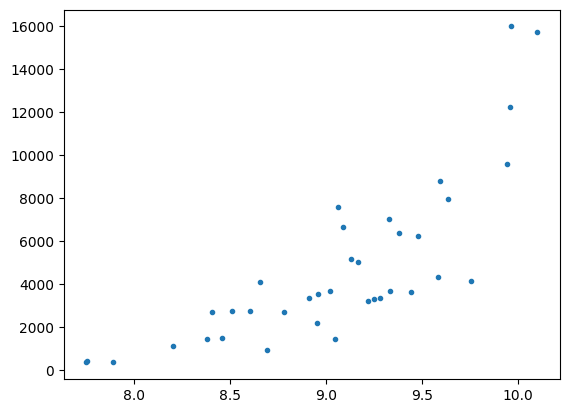

In [19]:
plt.plot(x,y,'.')

- let's try linear fit $y = \beta_0+\beta_1\times X$
- using statsmodels

In [20]:
import statsmodels.api as sm

In [21]:
y = df['afab_km2']                          # response array
X = sm.add_constant(df['vpd_hPa'])## add a constant for beta0
m1_lin = sm.OLS(y, X).fit()
m1_lin.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:               afab_km2   R-squared:                       0.627
Model:                            OLS   Adj. R-squared:                  0.617
Method:                 Least Squares   F-statistic:                     58.92
Date:                Wed, 07 Oct 2026   Prob (F-statistic):           5.24e-09
Time:                        17:52:13   Log-Likelihood:                -339.09
No. Observations:                  37   AIC:                             682.2
Df Residuals:                      35   BIC:                             685.4
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const      -4.057e+04   5914.718     -6.859      0.000   -5.26e+04   -2.86e+04
vpd_hPa     5008.8019    652.512      7.676      0.000    3684.132    6333.472
==============================================================================
Omnibus:                        5.280   Durbin-Watson:                   1.834
Prob(Omnibus):                  0.071   Jarque-Bera (JB):                3.823
Skew:                           0.679   Prob(JB):                        0.148
Kurtosis:                       3.797   Cond. No.                         139.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

- check fitted values

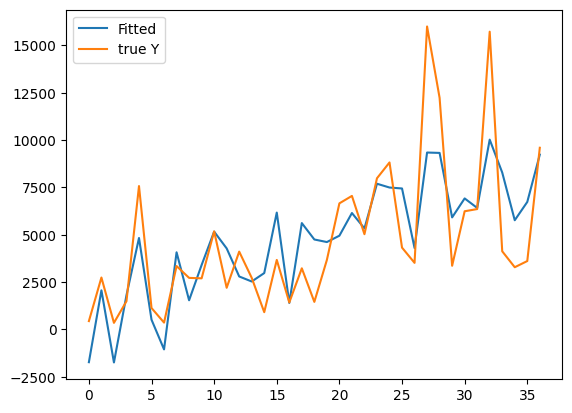

In [22]:
plt.plot(m1_lin.fittedvalues,label="Fitted")
plt.plot(y, label = "true Y")
plt.legend()

- check residual

In [23]:
import statsmodels.tsa.stattools as stattools
stattools.acf(m1_lin.resid,nlags=1)[1]

np.float64(0.07052958676311427)

- lets try fit $log(y) = \beta_0+\beta_1\times X$

In [24]:
m1_loglinear = sm.OLS(np.log(y), X).fit()
m1_loglinear.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:               afab_km2   R-squared:                       0.791
Model:                            OLS   Adj. R-squared:                  0.786
Method:                 Least Squares   F-statistic:                     132.8
Date:                Wed, 07 Oct 2026   Prob (F-statistic):           1.82e-13
Time:                        17:52:14   Log-Likelihood:                -20.790
No. Observations:                  37   AIC:                             45.58
Df Residuals:                      35   BIC:                             48.80
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -4.3752      1.086     -4.029      0.000      -6.580      -2.171
vpd_hPa        1.3807      0.120     11.525      0.000       1.138       1.624
==============================================================================
Omnibus:                        0.668   Durbin-Watson:                   1.848
Prob(Omnibus):                  0.716   Jarque-Bera (JB):                0.742
Skew:                          -0.163   Prob(JB):                        0.690
Kurtosis:                       2.388   Cond. No.                         139.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [25]:
stattools.acf(m1_loglinear.resid,nlags=1)[1]

np.float64(0.06867053821785953)

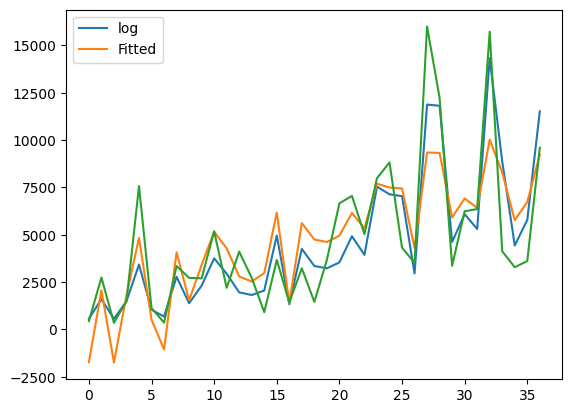

In [36]:
plt.plot(np.exp(m1_loglinear.fittedvalues), label="log")
plt.plot(m1_lin.fittedvalues,label="Fitted")
plt.legend()
plt.plot(y)

- plot the fitted line with a given VPD

In [39]:
xx = np.linspace(x.min(), x.max(), 200)
xx_vpd = sm.add_constant(xx)

xx_vpd

array([[ 1.        ,  7.75      ],
       [ 1.        ,  7.76180905],
       [ 1.        ,  7.77361809],
       [ 1.        ,  7.78542714],
       [ 1.        ,  7.79723618],
       [ 1.        ,  7.80904523],
       [ 1.        ,  7.82085427],
       [ 1.        ,  7.83266332],
       [ 1.        ,  7.84447236],
       [ 1.        ,  7.85628141],
       [ 1.        ,  7.86809045],
       [ 1.        ,  7.8798995 ],
       [ 1.        ,  7.89170854],
       [ 1.        ,  7.90351759],
       [ 1.        ,  7.91532663],
       [ 1.        ,  7.92713568],
       [ 1.        ,  7.93894472],
       [ 1.        ,  7.95075377],
       [ 1.        ,  7.96256281],
       [ 1.        ,  7.97437186],
       [ 1.        ,  7.9861809 ],
       [ 1.        ,  7.99798995],
       [ 1.        ,  8.00979899],
       [ 1.        ,  8.02160804],
       [ 1.        ,  8.03341709],
       [ 1.        ,  8.04522613],
       [ 1.        ,  8.05703518],
       [ 1.        ,  8.06884422],
       [ 1.        ,

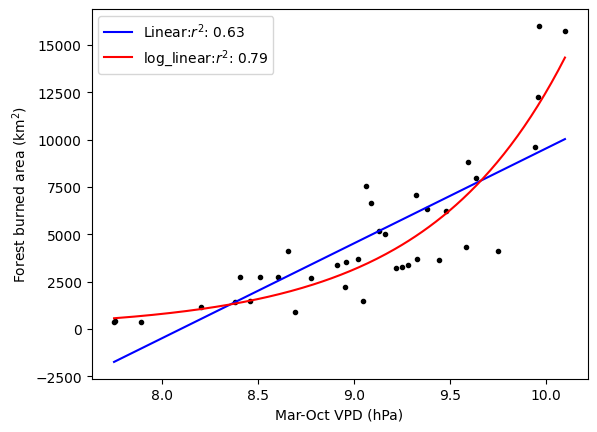

In [28]:
plt.plot(x,y,'k.')

### linear:
y_lin_fit = m1_lin.predict(xx_vpd)
plt.plot(xx,y_lin_fit,'b-',label=f"Linear:$r^2$: {m1_lin.rsquared:.2f}")
### poisson

logy_fit = m1_loglinear.predict(xx_vpd)   # fitted ln(AFAB)
y_fit    = np.exp(logy_fit)                # fitted AFAB (median), km²
plt.plot(xx,y_fit,'r-',label=f"log_linear:$r^2$: {m1_loglinear.rsquared:.2f}")
plt.legend()
plt.xlabel('Mar-Oct VPD (hPa)')
plt.ylabel('Forest burned area (km$^2$)')
plt.savefig('ols_afab_vpd.png', dpi=200)

### considering both VPD and wind

In [46]:
## need to modify X
X = sm.add_constant(df[['vpd_hPa', 'wind_ms']]) #add constant function will add a constant (B0, beta) to all the predictors
X.head()

,const,vpd_hPa,wind_ms
0,1.0,7.753,4.226
1,1.0,8.511,5.706
2,1.0,7.750,3.747
3,1.0,8.459,4.332
4,1.0,9.063,5.854


In [30]:
m2 = sm.OLS(np.log(y), X).fit()
m2.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:               afab_km2   R-squared:                       0.945
Model:                            OLS   Adj. R-squared:                  0.941
Method:                 Least Squares   F-statistic:                     289.6
Date:                Wed, 07 Oct 2026   Prob (F-statistic):           4.42e-22
Time:                        17:52:14   Log-Likelihood:                 3.7173
No. Observations:                  37   AIC:                            -1.435
Df Residuals:                      34   BIC:                             3.398
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -5.8126      0.587     -9.900      0.000      -7.006      -4.619
vpd_hPa        1.2804      0.064     20.156      0.000       1.151       1.409
wind_ms        0.5039      0.052      9.689      0.000       0.398       0.610
==============================================================================
Omnibus:                        0.477   Durbin-Watson:                   1.803
Prob(Omnibus):                  0.788   Jarque-Bera (JB):                0.553
Skew:                           0.241   Prob(JB):                        0.758
Kurtosis:                       2.643   Cond. No.                         161.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [31]:
print(m2.params)
print(f"R2 = {m2.rsquared:.3f}, adjusted R2 = {m2.rsquared_adj:.3f}")

const     -5.812557
vpd_hPa    1.280368
wind_ms    0.503903
dtype: float64
R2 = 0.945, adjusted R2 = 0.941


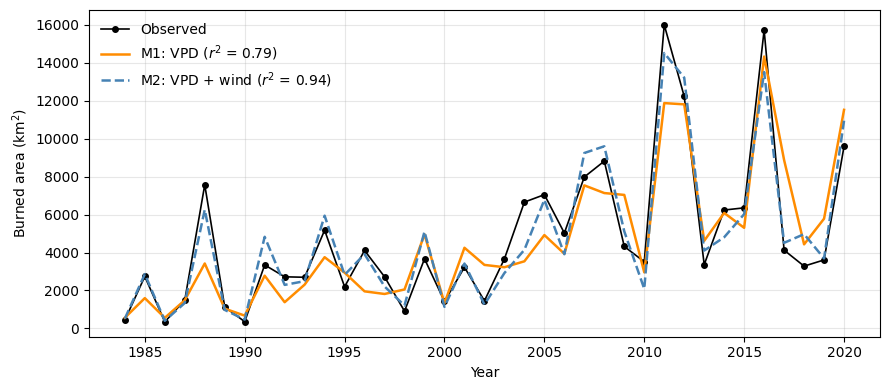

In [32]:
# Observed vs fitted
fig, ax = plt.subplots(figsize=(9, 4))

ax.plot(df["year"], y, "ko-", ms=4, lw=1.2, label="Observed")
ax.plot(df["year"], np.exp(m1_loglinear.fittedvalues), "-", color="darkorange", lw=1.8,
        label=f"M1: VPD ($r^2$ = {m1_loglinear.rsquared:.2f})")
ax.plot(df["year"], np.exp(m2.fittedvalues), "--", color="steelblue", lw=1.8,
        label=f"M2: VPD + wind ($r^2$ = {m2.rsquared_adj:.2f})")
ax.set_xlabel("Year")
ax.set_ylabel("Burned area (km$^2$)")
ax.grid(alpha=0.3)
ax.legend(frameon=False, loc="upper left")
fig.tight_layout()
fig.savefig("afab_poisson_fits.png", dpi=200)
plt.show()

### -- hands on --
- m3: add T to your predictors and
- m4: futhre add RH

In [42]:
df.head()

,year,vpd_hPa,n_fires,mean_fire_size_km2,afab_km2,wind_ms,temp_C,rh_pct
0,1984,7.753,47.0,9.304,437.3,4.226,20.50,67.94
1,1985,8.511,130.0,21.071,2739.3,5.706,20.17,63.31
2,1986,7.750,46.0,7.511,345.5,3.747,19.67,66.05
3,1987,8.459,114.0,13.052,1488.0,4.332,20.67,65.20
4,1988,9.063,255.0,29.689,7570.8,5.854,20.97,62.62


In [55]:
XX = sm.add_constant(df[['vpd_hPa', 'wind_ms', 'temp_C']]) #add constant function will add a constant (B0, beta) to all the predictors
XXX = sm.add_constant(df[['vpd_hPa', 'wind_ms', 'temp_C', 'rh_pct']])

In [56]:
m3 = sm.OLS(np.log(y), XX).fit()
m4 = sm.OLS(np.log(y), XXX).fit()

In [61]:
print(m3.params)
print(f"R2 = {m3.rsquared:.3f}, adjusted R2 = {m3.rsquared_adj:.3f}")

print(m4.params)
print(f"R2 = {m4.rsquared:.3f}, adjusted R2 = {m4.rsquared_adj:.3f}")

const     -7.304635
vpd_hPa    1.197885
wind_ms    0.508963
temp_C     0.105566
dtype: float64
R2 = 0.947, adjusted R2 = 0.942
const     -8.644231
vpd_hPa    1.308569
wind_ms    0.512681
temp_C     0.043179
rh_pct     0.025633
dtype: float64
R2 = 0.947, adjusted R2 = 0.940


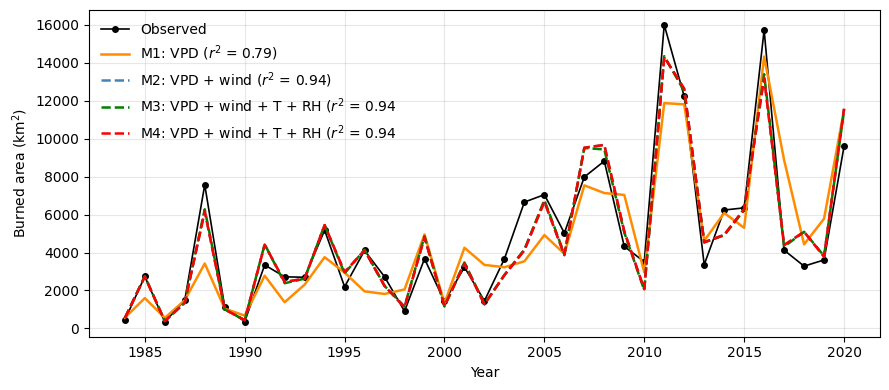

In [60]:
fig, ax = plt.subplots(figsize=(9, 4))

ax.plot(df["year"], y, "ko-", ms=4, lw=1.2, label="Observed")
ax.plot(df["year"], np.exp(m1_loglinear.fittedvalues), "-", color="darkorange", lw=1.8,
        label=f"M1: VPD ($r^2$ = {m1_loglinear.rsquared:.2f})")
ax.plot(df["year"], np.exp(m2.fittedvalues), "--", color="steelblue", lw=1.8,
        label=f"M2: VPD + wind ($r^2$ = {m2.rsquared_adj:.2f})")
ax.plot(df["year"], np.exp(m3.fittedvalues), "--", color="green", lw=1.8,
        label=f"M3: VPD + wind + T + RH ($r^2$ = {m3.rsquared_adj:.2f}")
ax.plot(df["year"], np.exp(m4.fittedvalues), "--", color="red", lw=1.8,
        label=f"M4: VPD + wind + T + RH ($r^2$ = {m4.rsquared_adj:.2f}")
ax.set_xlabel("Year")
ax.set_ylabel("Burned area (km$^2$)")
ax.grid(alpha=0.3)
ax.legend(frameon=False, loc="upper left")
fig.tight_layout()
fig.savefig("afab_poisson_fits.png", dpi=200)
plt.show()

# HW (bruned area model) -- hands on  --

HINT

- Use standardized predictors ($z_x$). When calculating the sample standard deviation, use n − 1 degrees of freedom (`ddof=1`).
- to build the model, compute the mean and standard deviation from the training data ONLY, and use them to standardize the training predictors.
- to make predictions, standardize the testing data with the training data's mean and standard deviation, not the testing data's own.

In [62]:
#question 3: X1 and X2
#question

df = pd.read_csv('WUS_afab.csv')
df.head()



,year,vpd_hPa,n_fires,mean_fire_size_km2,afab_km2,wind_ms,temp_C,rh_pct
0,1984,7.753,47.0,9.304,437.3,4.226,20.50,67.94
1,1985,8.511,130.0,21.071,2739.3,5.706,20.17,63.31
2,1986,7.750,46.0,7.511,345.5,3.747,19.67,66.05
3,1987,8.459,114.0,13.052,1488.0,4.332,20.67,65.20
4,1988,9.063,255.0,29.689,7570.8,5.854,20.97,62.62


In [ ]:
## need to modify X
X = sm.add_constant(df[['vpd_hPa', 'wind_ms']]) #add constant function will add a constant (B0, beta) to all the predictors
X.head()

,const,vpd_hPa,wind_ms
0,1.0,7.753,4.226
1,1.0,8.511,5.706
2,1.0,7.750,3.747
3,1.0,8.459,4.332
4,1.0,9.063,5.854


In [ ]:
m2 = sm.OLS(np.log(y), X).fit()
m2.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:               afab_km2   R-squared:                       0.945
Model:                            OLS   Adj. R-squared:                  0.941
Method:                 Least Squares   F-statistic:                     289.6
Date:                Wed, 07 Oct 2026   Prob (F-statistic):           4.42e-22
Time:                        17:52:14   Log-Likelihood:                 3.7173
No. Observations:                  37   AIC:                            -1.435
Df Residuals:                      34   BIC:                             3.398
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -5.8126      0.587     -9.900      0.000      -7.006      -4.619
vpd_hPa        1.2804      0.064     20.156      0.000       1.151       1.409
wind_ms        0.5039      0.052      9.689      0.000       0.398       0.610
==============================================================================
Omnibus:                        0.477   Durbin-Watson:                   1.803
Prob(Omnibus):                  0.788   Jarque-Bera (JB):                0.553
Skew:                           0.241   Prob(JB):                        0.758
Kurtosis:                       2.643   Cond. No.                         161.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [ ]:
# Write down the fitted equation and report the training R² and RMSE.
y= 1.2803(x1) + 0.5039(x2)-5.8126
R-squared = 0.945

In [64]:
train=np.arange(27)
test=np.arange(27,n)
y_training = df['afab_km2'].values[train]
z_vpd_testing = (df['vpd_hPa'].values[test]-df['vpd_hPa'].values[train].mean())/df['vpd_hPa'].values[train].std(ddof=1)
z_vpd_testing

array([2.17242989, 2.16484307, 0.87508356, 1.25442459, 1.06475408,
       2.43038179, 1.7722251 , 0.81818241, 1.1842465 , 2.13070238])